![imagen](https://cdn.foodbeast.com/content/wp-content/uploads/2012/03/beer-print-01-selectism.jpg)

# Ejercicio pandas estadística
Para este ejercicio se ha utilizado [un dataset de un concurso de kaggle](https://www.kaggle.com/nickhould/craft-cans), cuyo reto consiste en predecir el tipo de cerveza en función de sus características (nivel de alcohol, amargura, tamaño...).

# Ejercicio 1
Importa las librerias que consideres

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

## Ejercicio 2
1. Importa el dataset "datasets_beer.csv"
2. Imprime por pantalla los primeros registros.
3. ¿Cuáles son sus columnas?
4. ¿Qué dimensiones tiene el DataFrame?

In [33]:
# 1. Importar el dataset
df = pd.read_csv('data/datasets_beer.csv')

# 2. Primeros registros
df.head()

# 3. Columnas
df.columns

# 4. Dimensiones
df.shape

FileNotFoundError: [Errno 2] No such file or directory: 'data/datasets_beer.csv'

In [34]:
# Como nos da error, vamos a ver donde está el dataset. Con ayuda de Claude: 
# SOy tonto y me daba error por poner mal el nombre (BEERS, sin s al final), pero así aprendo a ver la ruta: 
import os
os.listdir()

['.DS_Store', 'birras_repaso.ipynb', 'birras_repaso_Andoni.ipynb', 'data']

In [35]:
df = pd.read_csv('data/datasets_beers.csv')
df.head(20)

,Unnamed: 0,abv,ibu,id,name,style,brewery_id,ounces
0,0,0.050,NaN,1436,Pub Beer,American Pale Lager,408,12.0
1,1,0.066,NaN,2265,Devil's Cup,American Pale Ale (APA),177,12.0
2,2,0.071,NaN,2264,Rise of the Phoenix,American IPA,177,12.0
3,3,0.090,NaN,2263,Sinister,American Double / Imperial IPA,177,12.0
4,4,0.075,NaN,2262,Sex and Candy,American IPA,177,12.0
5,5,0.077,NaN,2261,Black Exodus,Oatmeal Stout,177,12.0
6,6,0.045,NaN,2260,Lake Street Express,American Pale Ale (APA),177,12.0
7,7,0.065,NaN,2259,Foreman,American Porter,177,12.0
8,8,0.055,NaN,2258,Jade,American Pale Ale (APA),177,12.0
9,9,0.086,NaN,2131,Cone Crusher,American Double / Imperial IPA,177,12.0


In [36]:
# 1. Importar el dataset
df = pd.read_csv('data/datasets_beers.csv')

# 2. Primeros registros
df.head()



,Unnamed: 0,abv,ibu,id,name,style,brewery_id,ounces
0,0,0.050,NaN,1436,Pub Beer,American Pale Lager,408,12.0
1,1,0.066,NaN,2265,Devil's Cup,American Pale Ale (APA),177,12.0
2,2,0.071,NaN,2264,Rise of the Phoenix,American IPA,177,12.0
3,3,0.090,NaN,2263,Sinister,American Double / Imperial IPA,177,12.0
4,4,0.075,NaN,2262,Sex and Candy,American IPA,177,12.0


In [37]:
# 3. Columnas
df.columns


Index(['Unnamed: 0', 'abv', 'ibu', 'id', 'name', 'style', 'brewery_id',
       'ounces'],
      dtype='str')

In [38]:

# 4. Dimensiones
df.shape

(2410, 8)

## Ejercicio 3
[Elimina la columna "Unnamed: 0"](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.drop.html)

In [ ]:
df = df.drop(columns='Unnamed: 0')

# Cuando pandas guarda un CSV, a veces incluye el índice como una columna extra llamada Unnamed: 0. 
# Es basura, no aporta nada. .drop(columns='nombre') la elimina.
# Escribimos df = df.drop(...). Esto es importante: .drop() no modifica el DataFrame original,
# sino que devuelve uno nuevo sin esa columna. Si no escribieramos df = al principio, 
# el cambio se perdería y df seguiría teniendo la columna.


In [41]:
display(df)

,abv,ibu,id,name,style,brewery_id,ounces
0,0.050,NaN,1436,Pub Beer,American Pale Lager,408,12.0
1,0.066,NaN,2265,Devil's Cup,American Pale Ale (APA),177,12.0
2,0.071,NaN,2264,Rise of the Phoenix,American IPA,177,12.0
3,0.090,NaN,2263,Sinister,American Double / Imperial IPA,177,12.0
4,0.075,NaN,2262,Sex and Candy,American IPA,177,12.0
...,...,...,...,...,...,...,...
2405,0.067,45.0,928,Belgorado,Belgian IPA,424,12.0
2406,0.052,NaN,807,Rail Yard Ale,American Amber / Red Ale,424,12.0
2407,0.055,NaN,620,B3K Black Lager,Schwarzbier,424,12.0
2408,0.055,40.0,145,Silverback Pale Ale,American Pale Ale (APA),424,12.0


## Ejercicio 4
¿Cuántas filas y columnas tiene el dataset?

In [42]:
df.shape

(2410, 7)

In [46]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2410 entries, 0 to 2409
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   abv         2348 non-null   float64
 1   ibu         1405 non-null   float64
 2   id          2410 non-null   int64  
 3   name        2410 non-null   str    
 4   style       2405 non-null   str    
 5   brewery_id  2410 non-null   int64  
 6   ounces      2410 non-null   float64
dtypes: float64(3), int64(2), str(2)
memory usage: 131.9 KB


## Ejercicio 5
¿De qué tipo son los datos?

In [45]:
df.dtypes

abv           float64
ibu           float64
id              int64
name              str
style             str
brewery_id      int64
ounces        float64
dtype: object

## Ejercicio 6
Obtén en un nuevo DataFrame un resumen con las principales estadísticas de las columnas numéricas: mean, max, count, cuartiles...

In [ ]:
resumen = df.describe()
resumen


,abv,ibu,id,brewery_id,ounces
count,2348.000000,1405.000000,2410.000000,2410.000000,2410.000000
mean,0.059773,42.713167,1431.113278,231.749793,13.592241
std,0.013542,25.954066,752.459975,157.685604,2.352204
min,0.001000,4.000000,1.000000,0.000000,8.400000
25%,0.050000,21.000000,808.250000,93.000000,12.000000
50%,0.056000,35.000000,1453.500000,205.000000,12.000000
75%,0.067000,64.000000,2075.750000,366.000000,16.000000
max,0.128000,138.000000,2692.000000,557.000000,32.000000


## Ejercicio 7
¿Cuántas birras hay de cada estilo en este dataset? [Investiga en la documentación de Series](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.html) si puedes hacer un conteo de valores.

In [51]:
# value_counts() es un método de una Serie (columna) que cuenta cuántas veces aparece cada valor distinto, 
# ordenado de mayor a menor. Es exactamente lo que necesitas para saber cuántas cervezas hay de cada estilo. 
# Lo llamas sobre df['style'] porque style es la columna que contiene el estilo de cada cerveza.

df['style'].value_counts()

style
American IPA                      424
American Pale Ale (APA)           245
American Amber / Red Ale          133
American Blonde Ale               108
American Double / Imperial IPA    105
                                 ... 
American Malt Liquor                1
Grisette                            1
Flanders Oud Bruin                  1
Braggot                             1
Low Alcohol Beer                    1
Name: count, Length: 99, dtype: int64

In [ ]:
# con nunique() cuenta cuántos valores únicos hay en la columna, es decir, cuántos estilos distintos existen en el dataset.
# Eso sí daría el número total de estilos diferentes.
# La diferencia entre los dos es esta:

# value_counts() → te dice cuántas cervezas hay de cada estilo
# nunique() → te dice cuántos estilos distintos hay en total

df['style'].nunique()
# El ejercicio 7 nos pregunta lo primero: cuantas cervezas hay de CADA ESTILO. 

99

## Ejercicio 8
1. Imprime por pantalla los registros desde el décimo hasta el vigésimo
2. De esos registros, imprime por pantalla desde la columna `name` a `ounces`, ambas incluidas
3. Quédate con las columnas `abv`, `ibu` y `ounces`, y además quédate sólo con los registros 10 al 20.
4. Convierte el resultado del apartado 3 en un array de `numpy`

In [ ]:
# .iloc selecciona por posición numérica (como los índices de una lista: 0, 1, 2...)
# .loc selecciona por etiqueta (el nombre real del índice o de la columna)

In [ ]:
# 1. Registros del décimo al vigésimo 
# Estamos hablando de FILAS
df.iloc[9:20]

,abv,ibu,id,name,style,brewery_id,ounces
9,0.086,NaN,2131,Cone Crusher,American Double / Imperial IPA,177,12.0
10,0.072,NaN,2099,Sophomoric Saison,Saison / Farmhouse Ale,177,12.0
11,0.073,NaN,2098,Regional Ring Of Fire,Saison / Farmhouse Ale,177,12.0
12,0.069,NaN,2097,Garce Selé,Saison / Farmhouse Ale,177,12.0
13,0.085,NaN,1980,Troll Destroyer,Belgian IPA,177,12.0
14,0.061,60.0,1979,Bitter Bitch,American Pale Ale (APA),177,12.0
15,0.060,NaN,2318,Ginja Ninja,Cider,154,12.0
16,0.060,NaN,2170,Cherried Away,Cider,154,12.0
17,0.060,NaN,2169,Rhubarbarian,Cider,154,12.0
18,0.060,NaN,1502,BrightCider,Cider,154,12.0


In [ ]:
# 2. De esos registros, desde la columna 'name' hasta 'ounces'
df.loc[9:20, 'name':'ounces']

# Aquí usamos .loc porque estamos seleccionando por nombre de columna. 
# La diferencia con .iloc es que .loc sí incluye el último elemento del rango, tanto en filas como en columnas.

,name,style,brewery_id,ounces
9,Cone Crusher,American Double / Imperial IPA,177,12.0
10,Sophomoric Saison,Saison / Farmhouse Ale,177,12.0
11,Regional Ring Of Fire,Saison / Farmhouse Ale,177,12.0
12,Garce Selé,Saison / Farmhouse Ale,177,12.0
13,Troll Destroyer,Belgian IPA,177,12.0
14,Bitter Bitch,American Pale Ale (APA),177,12.0
15,Ginja Ninja,Cider,154,12.0
16,Cherried Away,Cider,154,12.0
17,Rhubarbarian,Cider,154,12.0
18,BrightCider,Cider,154,12.0


In [55]:
# 3. Solo columnas abv, ibu y ounces, filas 10 a 20
df.loc[9:20, ['abv', 'ibu', 'ounces']]
# Cuando las columnas que quieres no son consecutivas sino específicas, las pasamos como una lista dentro de corchetes.

,abv,ibu,ounces
9,0.086,NaN,12.0
10,0.072,NaN,12.0
11,0.073,NaN,12.0
12,0.069,NaN,12.0
13,0.085,NaN,12.0
14,0.061,60.0,12.0
15,0.060,NaN,12.0
16,0.060,NaN,12.0
17,0.060,NaN,12.0
18,0.060,NaN,12.0


In [ ]:
# 4. Convertir a array de numpy
array = df.loc[9:20, ['abv', 'ibu', 'ounces']].values
array
# .values es un atributo de cualquier DataFrame o Serie que devuelve los datos como un array de numpy, 
# sin los nombres de columnas ni el índice. 
# Es útil cuando quieres pasar los datos a un algoritmo de machine learning, por ejemplo.

array([[ 0.086,    nan, 12.   ],
       [ 0.072,    nan, 12.   ],
       [ 0.073,    nan, 12.   ],
       [ 0.069,    nan, 12.   ],
       [ 0.085,    nan, 12.   ],
       [ 0.061, 60.   , 12.   ],
       [ 0.06 ,    nan, 12.   ],
       [ 0.06 ,    nan, 12.   ],
       [ 0.06 ,    nan, 12.   ],
       [ 0.06 ,    nan, 12.   ],
       [ 0.082,    nan, 12.   ],
       [ 0.082,    nan, 12.   ]])

## Ejercicio 9
¿Cuántas onzas pesan todas las birras del dataset?

In [58]:
df[['ounces']].sum()

ounces    32757.3
dtype: float64

## Ejercicio 10
El amargor de las cervezas se mide por su nivel de IBUs.
1. ¿Cuál es el amargor medio de las cervezas?
2. ¿El máximo? ¿Y el mínimo?
3. ¿Qué cerveza es la que tiene el amargor máximo? ¿Cuál es la de amargor mínimo?

In [75]:
# 1. Amargor medio
df['ibu'].mean()

np.float64(42.71316725978647)

In [ ]:
# 2. Máximo 
df['ibu'].max()


np.float64(138.0)

In [ ]:
# Mínimo
df['ibu'].min()

np.float64(4.0)

In [79]:
# 3. Cerveza con amargor máximo -> esto me ha costado muchísimo, explicación detallada debajo (ayuda de Claude IA)
df[df['ibu'] == df['ibu'].max()]

,abv,ibu,id,name,style,brewery_id,ounces
147,0.082,138.0,980,Bitter Bitch Imperial IPA,American Double / Imperial IPA,374,12.0


In [ ]:

# 4. Cerveza con amargor mínimo
df[df['ibu'] == df['ibu'].min()]


,abv,ibu,id,name,style,brewery_id,ounces
106,0.056,4.0,1350,Summer Solstice,Cream Ale,171,12.0
112,0.056,4.0,753,Summer Solstice Cerveza Crema (2009),Cream Ale,171,12.0
117,0.056,4.0,77,Summer Solstice (2011),Cream Ale,171,12.0


In [ ]:
'''
df['ibu'] == df['ibu'].max()
```

Pandas coge cada valor de la columna `ibu` y lo compara con el máximo. Si son iguales, pone `True`. 
Si no son iguales, pone `False`. El resultado es una Serie entera de `True` y `False`, una por cada fila.

Algo así:
```
0      False
1      False
2      False
3      True     ← esta cerveza tiene el ibu máximo
4      False
...

Ahora metemos esa Serie de True/False dentro de df[...] y pandas te devuelve solo las filas donde hay True:
df[df['ibu'] == df['ibu'].max()]
'''

## Ejercicio 11
No queda muy claro cuánto de dispar, de dispersa, es la medida de IBU. Mediante estadística descriptiva (una o dos métricas, sin gráficas), razona la dispersión de la variable IBU.

In [68]:
print("Desviación estándar:", df['ibu'].std())
print("Coeficiente de variación:", df['ibu'].std() / df['ibu'].mean()*100,"%")

Desviación estándar: 25.954065911259317
Coeficiente de variación: 60.76361828520853 %


In [71]:
# CON AYUDA DE LA IA

# La media es el valor central alrededor del cual giran todos los datos.
# Es la suma de todos los IBUs dividida entre el número de cervezas.
media = df['ibu'].mean()
print(f"La media de IBU es: {media:.2f}")

# La desviación estándar (std) mide cuánto se alejan los valores de la media en promedio.
# Si es alta, los valores están muy repartidos. Si es baja, están muy juntos.
std = df['ibu'].std()
print(f"La desviación estándar de IBU es: {std:.2f}")

# El coeficiente de variación es la desviación estándar dividida entre la media,
# multiplicada por 100 para expresarlo en porcentaje.
# Nos dice: "la dispersión representa un X% de la media".
# Por encima del 30% se considera dispersión alta.
cv = (df['ibu'].std() / df['ibu'].mean()) * 100
print(f"El coeficiente de variación de IBU es: {cv:.2f}%")

'''
**Dos cosas nuevas que aparecen aquí que no hemos visto antes:**

`media = df['ibu'].mean()` — Guardamos el resultado en una variable. Así no tenemos que recalcularlo cada vez y podemos reutilizarlo.

`f"texto {variable:.2f}"` — Esto se llama **f-string**. Es una forma de meter variables dentro de un texto. 
La `f` antes de las comillas le dice a Python que dentro del texto puede haber variables entre llaves `{}`. 
El `:.2f` significa "muéstrame este número con 2 decimales". Sin eso verías números larguísimos como `42.711750639386196`.

---

Cuando lo ejecutes verás algo así:

La media de IBU es: 42.71
La desviación estándar de IBU es: 25.95
El coeficiente de variación de IBU es: 60.77%

# INTERPRETACIÓN:
# El IBU medio de las cervezas del dataset es ~42 unidades.
# La desviación estándar es ~26, lo que significa que la mayoría de cervezas
# se alejan unos 26 puntos de esa media.
# El coeficiente de variación es ~60%, lo que indica dispersión ALTA:
# hay cervezas muy suaves y cervezas muy amargas conviviendo en el mismo dataset.
# La media por sí sola no describe bien la realidad de estos datos.
'''

La media de IBU es: 42.71
La desviación estándar de IBU es: 25.95
El coeficiente de variación de IBU es: 60.76%


'\n**Dos cosas nuevas que aparecen aquí que no hemos visto antes:**\n\n`media = df[\'ibu\'].mean()` — Guardamos el resultado en una variable. Así no tenemos que recalcularlo cada vez y podemos reutilizarlo.\n\n`f"texto {variable:.2f}"` — Esto se llama **f-string**. Es una forma de meter variables dentro de un texto. \nLa `f` antes de las comillas le dice a Python que dentro del texto puede haber variables entre llaves `{}`. \nEl `:.2f` significa "muéstrame este número con 2 decimales". Sin eso verías números larguísimos como `42.711750639386196`.\n\n---\n\nCuando lo ejecutes verás algo así:\n\nLa media de IBU es: 42.71\nLa desviación estándar de IBU es: 25.95\nEl coeficiente de variación de IBU es: 60.77%\n\n# INTERPRETACIÓN:\n# El IBU medio de las cervezas del dataset es ~42 unidades.\n# La desviación estándar es ~26, lo que significa que la mayoría de cervezas\n# se alejan unos 26 puntos de esa media.\n# El coeficiente de variación es ~60%, lo que indica dispersión ALTA:\n# hay cerve

## Ejercicio 12
¿Existe alguna relación lineal entre las variables numéricas del dataset? Intenta pintar este razonamiento mediante un gráfico

In [73]:
# Paso 1: calcular la correlación entre todas las columnas numéricas
correlacion = df.corr(numeric_only=True)
print(correlacion)

# df.corr() coge todas las columnas numéricas de tu DataFrame y calcula la correlación entre cada par posible. 
# El resultado es una tabla donde en cada celda hay un número entre -1 y 1.
# numeric_only=True le dice a pandas que ignore las columnas de texto como name o style, 
# porque no tiene sentido calcular la correlación de palabras.

                 abv       ibu        id  brewery_id    ounces
abv         1.000000  0.670621  0.042811   -0.098632  0.172529
ibu         0.670621  1.000000  0.000485   -0.004875  0.054691
id          0.042811  0.000485  1.000000   -0.504030  0.100843
brewery_id -0.098632 -0.004875 -0.504030    1.000000 -0.133762
ounces      0.172529  0.054691  0.100843   -0.133762  1.000000


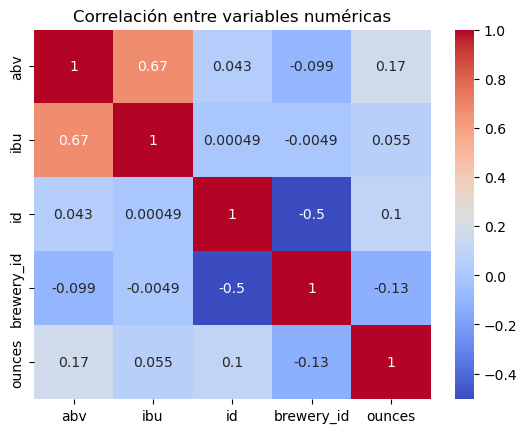

In [81]:
# Paso 1: calcular la correlación
correlacion = df.corr(numeric_only=True)

# Paso 2: pintarla como heatmap para que sea fácil de leer
sns.heatmap(correlacion, annot=True, cmap='coolwarm')
plt.title('Correlación entre variables numéricas')
plt.show()

In [82]:
'''correlacion → le pasas la tabla de correlaciones que calculaste en el paso 1. Es lo que quieres visualizar.
annot=True → "annot" viene de "annotate", que significa anotar. 
Con True le dices que además de los colores, escriba el número exacto dentro de cada celda. Así ves el color Y el número a la vez.
cmap='coolwarm' → "cmap" viene de "colormap", que es la paleta de colores que vas a usar. coolwarm 
es una paleta que va del azul (frío, correlación negativa) al rojo (caliente, correlación positiva), 
pasando por blanco en el centro (sin correlación). Es la más usada para este tipo de gráfico porque es muy intuitiva.
plt.title(...) → añade un título al gráfico para que quede claro qué estás viendo.
plt.show() → muestra el gráfico en pantalla. Sin esta línea el gráfico se genera pero no se muestra.
'''

'correlacion → le pasas la tabla de correlaciones que calculaste en el paso 1. Es lo que quieres visualizar.\nannot=True → "annot" viene de "annotate", que significa anotar. \nCon True le dices que además de los colores, escriba el número exacto dentro de cada celda. Así ves el color Y el número a la vez.\ncmap=\'coolwarm\' → "cmap" viene de "colormap", que es la paleta de colores que vas a usar. coolwarm \nes una paleta que va del azul (frío, correlación negativa) al rojo (caliente, correlación positiva), \npasando por blanco en el centro (sin correlación). Es la más usada para este tipo de gráfico porque es muy intuitiva.\nplt.title(...) → añade un título al gráfico para que quede claro qué estás viendo.\nplt.show() → muestra el gráfico en pantalla. Sin esta línea el gráfico se genera pero no se muestra.\n'

In [83]:
# INTERPRETACIÓN:
# La diagonal siempre vale 1.0 porque cada variable se correlaciona perfectamente consigo misma.
# Valores cercanos a 1 → relación positiva: cuando una sube, la otra también.
# Valores cercanos a -1 → relación negativa: cuando una sube, la otra baja.
# Valores cercanos a 0 → no hay relación entre esas dos variables.
# El heatmap convierte esos números en colores para facilitar la lectura visual.

## Ejercicio 13
Representa el nivel de alcohol (columna `abv`) en un histograma. ¿Se trata de una distribución simétrica o asimétrica?

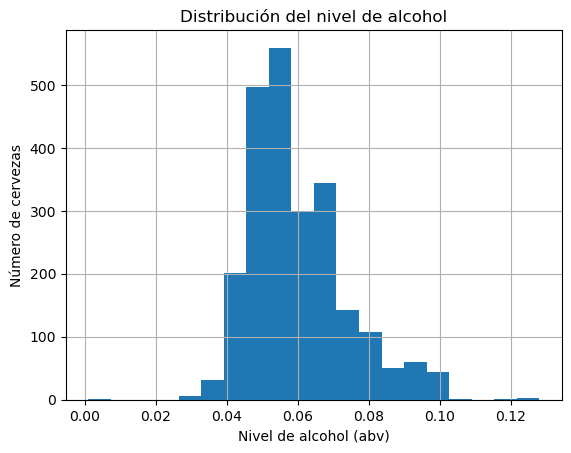

In [ ]:
# Con ayuda de la IA

df['abv'].hist(bins=20)
plt.xlabel('Nivel de alcohol (abv)')
plt.ylabel('Número de cervezas')
plt.title('Distribución del nivel de alcohol')
plt.show()


In [ ]:
'''
**Cada línea explicada:**

`df['abv'].hist(bins=20)` — seleccionas la columna `abv` y llamas `.hist()` que genera el histograma. Le dices que quieres 20 bins.

`plt.xlabel(...)` — añade una etiqueta al eje horizontal (el de abajo) para que se sepa qué representa.

`plt.ylabel(...)` — añade una etiqueta al eje vertical (el de la izquierda) para que se sepa qué representa la altura de cada barra.

`plt.title(...)` — añade un título al gráfico.

`plt.show()` — muestra el gráfico. Sin esta línea no aparece nada en pantalla.

---

### Tercero: ¿qué es una distribución simétrica o asimétrica?

Esto es lo que te pregunta el ejercicio y necesitas entenderlo antes de ver tu resultado.

**Distribución simétrica** — la montaña del histograma está perfectamente centrada. El lado izquierdo y el lado derecho son un espejo. Como esto:
```
        █
      █████
    █████████
  █████████████
```

**Distribución asimétrica hacia la derecha** — la montaña está desplazada hacia la izquierda y tiene una cola larga hacia la derecha. Significa que la mayoría de valores son bajos pero hay algunos valores muy altos que tiran hacia la derecha:
```
  █
  ███
  █████
  ████████▄▄__
```

**Distribución asimétrica hacia la izquierda** — al revés. La cola larga está hacia la izquierda. La mayoría de valores son altos pero hay algunos muy bajos:
```
              █
           ████
        ███████
__▄▄████████████
'''

## Ejercicio 14
Representa mediante un *boxplot* de `seaborn` la variable `abv`

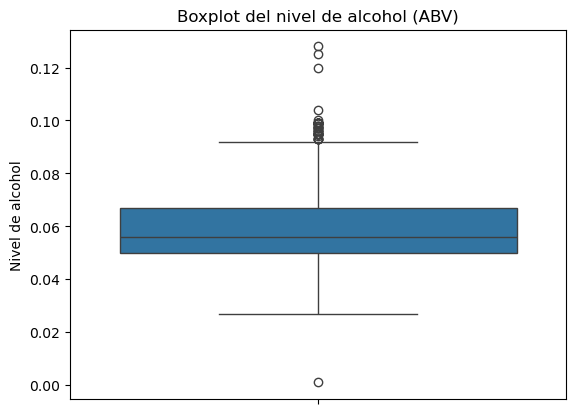

In [86]:
sns.boxplot(y=df['abv'])
plt.title('Boxplot del nivel de alcohol (ABV)')
plt.ylabel('Nivel de alcohol')
plt.show()

In [87]:
## INTERPRETACIÓN DEL BOXPLOT:
# La caja muestra el 50% central de las cervezas (entre Q1 y Q3).
# La línea dentro de la caja es la mediana: el valor exactamente del medio.
# Los bigotes llegan hasta el mínimo y el máximo no atípicos.
# Los puntos sueltos fuera de los bigotes son outliers:
# cervezas con un nivel de alcohol tan alto que se salen del patrón normal.

In [ ]:
'''

Un boxplot es otro tipo de gráfico para visualizar cómo están distribuidos los datos. 
Pero a diferencia del histograma, que te muestra todas las barras, el boxplot te resume los datos en 5 números clave de un solo vistazo.
Para entenderlo vamos con un ejemplo sencillo. Imagina que tienes las notas de 10 alumnos ordenadas de menor a mayor:
3, 4, 5, 5, 6, 6, 7, 7, 8, 10
El boxplot usa estos 5 números:

1. El mínimo → el valor más bajo. En este caso: 3
2. El percentil 25 (Q1) → el valor por debajo del cual está el 25% de los datos. 
Es decir, la nota que deja al 25% de alumnos por debajo. En este caso: 5
Espera. ¿Qué es un percentil? Es simplemente una posición. 
El percentil 25 es el punto donde el 25% de los datos están por debajo. 
Si eres el percentil 25 en altura, el 25% de la gente es más baja que tú.
3. La mediana (Q2) → el valor del medio exacto. El 50% de datos están por debajo y el 50% por encima. En este caso: 6
La mediana es diferente a la media. La media suma todo y divide. La mediana simplemente busca el valor del centro. 
Si tienes 3, 5 y 100, la media es 36 pero la mediana es 5. La mediana no se deja engañar por valores extremos.
4. El percentil 75 (Q3) → el valor por debajo del cual está el 75% de los datos. En este caso: 7
5. El máximo → el valor más alto. En este caso: 10

'''

## Ejercicio 15
1. ¿Qué estilos son los que tienen en media más alcohol?
2. ¿Y los estilos que son en media más amargos?

In [90]:
# Parte 1: estilos con más alcohol en media
'''
df.groupby('style') — agrupa el DataFrame por la columna style. 
En este momento pandas ha separado internamente todas las cervezas en grupos, uno por cada estilo distinto. 
Todavía no hemos calculado nada, solo has dicho "quiero trabajar por grupos de estilo".
['abv'] — de cada grupo, selecciona solo la columna abv. Le estamoss diciendo a pandas "dentro de cada grupo de estilo, 
quiero trabajar con los valores de alcohol".
.mean() — calcula la media de abv dentro de cada grupo. 
El resultado es una Serie donde el índice son los nombres de los estilos y los valores son la media de alcohol de cada uno.
.sort_values(ascending=False) — ordena el resultado de mayor a menor. ascending=False significa "orden descendente", 
es decir, el más alto primero. Si pusieras ascending=True ordenaría de menor a mayor.
.head(10) — muestra solo los 10 primeros. Sin esto verías todos los estilos, que son muchos, y sería difícil de leer.
Con .head(10) nos quedamos con el top 10.
'''

df.groupby('style')['abv'].mean().sort_values(ascending=False).head(10)

style
English Barleywine                  0.107667
Quadrupel (Quad)                    0.104000
American Barleywine                 0.099000
American Malt Liquor                0.099000
Russian Imperial Stout              0.097636
American Double / Imperial Stout    0.093667
American Double / Imperial IPA      0.087369
Tripel                              0.086818
Baltic Porter                       0.085167
Belgian Strong Pale Ale             0.084000
Name: abv, dtype: float64

In [91]:
# Parte 2: estilos más amargos en media
df.groupby('style')['ibu'].mean().sort_values(ascending=False).head(10)

style
American Barleywine                   96.000000
American Double / Imperial IPA        93.320000
Russian Imperial Stout                86.500000
American Double / Imperial Pilsner    85.000000
Belgian Strong Dark Ale               72.000000
American Black Ale                    68.900000
American IPA                          67.634551
English Barleywine                    66.666667
English Stout                         66.000000
American Strong Ale                   65.416667
Name: ibu, dtype: float64

In [ ]:
# INTERPRETACIÓN:
# groupby agrupa todas las cervezas por estilo.
# .mean() calcula la media de alcohol o amargor dentro de cada grupo.
# sort_values(ascending=False) ordena de mayor a menor.
# .head(10) muestra solo el top 10 para facilitar la lectura.
# Los estilos con MÁS ALCOHOL son cervezas de alta graduación como
# Quadrupels o Barleywines.
# Los estilos MÁS AMARGOS son las IPAs dobles e imperiales,
# diseñadas específicamente para tener un amargor extremo.

In [93]:
# Parte 1: estilos con más alcohol en media
print(" Los 10 estilos de cerveza con MÁS ALCOHOL de media son:")
print("")
print(df.groupby('style')['abv'].mean().sort_values(ascending=False).head(10))

print("")
print("------------------------------------------------------------")
print("")

# Parte 2: estilos más amargos en media
print("Los 10 estilos de cerveza MÁS AMARGOS de media son:")
print("")
print(df.groupby('style')['ibu'].mean().sort_values(ascending=False).head(10))

 Los 10 estilos de cerveza con MÁS ALCOHOL de media son:

style
English Barleywine                  0.107667
Quadrupel (Quad)                    0.104000
American Barleywine                 0.099000
American Malt Liquor                0.099000
Russian Imperial Stout              0.097636
American Double / Imperial Stout    0.093667
American Double / Imperial IPA      0.087369
Tripel                              0.086818
Baltic Porter                       0.085167
Belgian Strong Pale Ale             0.084000
Name: abv, dtype: float64

------------------------------------------------------------

Los 10 estilos de cerveza MÁS AMARGOS de media son:

style
American Barleywine                   96.000000
American Double / Imperial IPA        93.320000
Russian Imperial Stout                86.500000
American Double / Imperial Pilsner    85.000000
Belgian Strong Dark Ale               72.000000
American Black Ale                    68.900000
American IPA                          67.634551
En

## Ejercicio 16
Carga el datasets de cervecerias `datasets_breweries.csv`

In [94]:
breweries = pd.read_csv('data/datasets_breweries.csv')
print("Primeras filas del dataset de cervecerías:")
print("")
print(breweries.head())
print("")
print("Dimensiones:", breweries.shape)
print("")
print("Columnas:", breweries.columns.tolist())

Primeras filas del dataset de cervecerías:

   Unnamed: 0                       name           city state
0           0         NorthGate Brewing     Minneapolis    MN
1           1  Against the Grain Brewery     Louisville    KY
2           2   Jack's Abby Craft Lagers     Framingham    MA
3           3  Mike Hess Brewing Company      San Diego    CA
4           4    Fort Point Beer Company  San Francisco    CA

Dimensiones: (558, 4)

Columnas: ['Unnamed: 0', 'name', 'city', 'state']


## Ejercicio 17
1. Renombra la columna `Unnamed: 0` como `brewery_id`
2. Renombra también la columna `name` por `brewery_name`. ¿Puedes hacer ambos apartados en una sola sentencia?

In [95]:
breweries = breweries.rename(columns={
    'Unnamed: 0': 'brewery_id',
    'name': 'brewery_name'
})

print("Columnas después de renombrar:")
print(breweries.columns.tolist())
print("")
print(breweries.head())

Columnas después de renombrar:
['brewery_id', 'brewery_name', 'city', 'state']

   brewery_id               brewery_name           city state
0           0         NorthGate Brewing     Minneapolis    MN
1           1  Against the Grain Brewery     Louisville    KY
2           2   Jack's Abby Craft Lagers     Framingham    MA
3           3  Mike Hess Brewing Company      San Diego    CA
4           4    Fort Point Beer Company  San Francisco    CA


## Ejercicio 18
Junta los dos datasets que tienes

In [96]:
df_total = pd.merge(df, breweries, on='brewery_id')

print("Dimensiones del dataset combinado:", df_total.shape)
print("")
print("Columnas del dataset combinado:")
print(df_total.columns.tolist())
print("")
print("Primeras filas:")
print(df_total.head())

Dimensiones del dataset combinado: (2410, 10)

Columnas del dataset combinado:
['abv', 'ibu', 'id', 'name', 'style', 'brewery_id', 'ounces', 'brewery_name', 'city', 'state']

Primeras filas:
     abv  ibu    id                 name                           style  \
0  0.050  NaN  1436             Pub Beer             American Pale Lager   
1  0.066  NaN  2265          Devil's Cup         American Pale Ale (APA)   
2  0.071  NaN  2264  Rise of the Phoenix                    American IPA   
3  0.090  NaN  2263             Sinister  American Double / Imperial IPA   
4  0.075  NaN  2262        Sex and Candy                    American IPA   

   brewery_id  ounces               brewery_name  city state  
0         408    12.0  10 Barrel Brewing Company  Bend    OR  
1         177    12.0        18th Street Brewery  Gary    IN  
2         177    12.0        18th Street Brewery  Gary    IN  
3         177    12.0        18th Street Brewery  Gary    IN  
4         177    12.0        18th Str

In [97]:
# pd.merge() une dos DataFrames buscando filas con el mismo valor
# en la columna de unión, en este caso 'brewery_id'.
# Usamos on='brewery_id' porque la columna se llama igual en los dos datasets.
# Guardamos el resultado en df_total para no machacar df ni breweries.
# A partir de aquí trabajamos con df_total que tiene toda la info junta:
# cada fila es una cerveza con los datos de su cervecería incluidos.

## Ejercicio 19
1. ¿Cuántos estados diferentes hay?
2. ¿Y ciudades diferentes?
3. ¿Cuántas cervecerías hay?

In [98]:
print("Número de estados diferentes:", df_total['state'].nunique())
print("")
print("Número de ciudades diferentes:", df_total['city'].nunique())
print("")
print("Número de cervecerías diferentes:", df_total['brewery_name'].nunique())

Número de estados diferentes: 51

Número de ciudades diferentes: 384

Número de cervecerías diferentes: 551


## Ejercicio 20
Agrupa por estado y ciudad, la media, mediana y máximo nivel de alcohol

In [99]:
resultado = df_total.groupby(['state', 'city'])['abv'].agg(['mean', 'median', 'max'])

print("Media, mediana y máximo de alcohol por estado y ciudad:")
print("")
print(resultado)

Media, mediana y máximo de alcohol por estado y ciudad:

                      mean  median    max
state city                               
AK    Anchorage   0.054200  0.0520  0.063
      Juneau      0.053000  0.0530  0.053
      Soldotna    0.058500  0.0580  0.068
      Talkeetna   0.059500  0.0585  0.065
AL    Birmingham  0.065400  0.0600  0.093
...                    ...     ...    ...
WI    Wilson      0.055000  0.0550  0.055
WV    Lewisburg   0.062000  0.0620  0.067
WY    Jackson     0.054857  0.0520  0.068
      Pinedale    0.061000  0.0610  0.072
      Sheridan    0.052833  0.0480  0.070

[401 rows x 3 columns]


In [100]:
# groupby(['state', 'city']) agrupa por dos columnas a la vez.
# Crea un grupo para cada combinación única de estado + ciudad.
# .agg(['mean', 'median', 'max']) aplica tres funciones a la vez.
# Usamos media Y mediana juntas porque si están muy separadas
# significa que hay outliers distorsionando los datos.
# Si están cerca, los datos son uniformes dentro de ese grupo.

## Ejercicio 21
¿Cuáles son las cervezas más amargas que se consumen en Indiana, estado = `IN`?

In [101]:
# Paso 1: filtramos con filtrado booleano para quedarnos solo con Indiana.
# OJO: el estado tiene un espacio delante (' IN'), no es ('IN').
# Este es un error muy común en datasets reales: espacios invisibles
# que hacen que el filtro no encuentre nada y devuelva un DataFrame vacío.
# Paso 2: sort_values('ibu', ascending=False) ordena de más amargo a menos.
# Seleccionamos solo las columnas relevantes para que el resultado sea legible.

indiana = df_total[df_total['state'] == ' IN'].sort_values('ibu', ascending=False)

print("Cervezas más amargas de Indiana, ordenadas de mayor a menor amargor:")
print("")
print(indiana[['name', 'brewery_name', 'ibu', 'city']].head(10))

Cervezas más amargas de Indiana, ordenadas de mayor a menor amargor:

                                name              brewery_name    ibu  \
479                 Hopkick Dropkick          Burn 'Em Brewing  115.0   
2191           Overlord Imperial IPA   Tin Man Brewing Company  115.0   
811                   Half Cycle IPA         Flat 12 Bierwerks  104.0   
2062                            Isis  Sun King Brewing Company   91.0   
2189                            Csar   Tin Man Brewing Company   90.0   
850                       The Gadget     Four Fathers Brewing    90.0   
483                   3:33 Black IPA          Burn 'Em Brewing   86.0   
1623               Mound Builder IPA  People's Brewing Company   77.0   
2047         Grapefruit Jungle (GFJ)  Sun King Brewing Company   77.0   
2064  Grapefruit Jungle (GFJ) (2011)  Sun King Brewing Company   77.0   

               city  
479   Michigan City  
2191     Evansville  
811    Indianapolis  
2062   Indianapolis  
2189     Evansvi

## Ejercicio 22
Obtén una tabla con los principales estadísticos del campo `ibu`,  a nivel ciudad

In [ ]:
# groupby('city') agrupa todas las cervezas por ciudad.
# .describe() calcula todos los estadísticos principales de golpe:
# count (cuántas cervezas), mean (media), std (desviación estándar),
# min, percentiles 25/50/75 y max.
# El resultado es una tabla con una fila por ciudad y una columna
# por cada estadístico. Ciudades con count bajo tienen pocos datos
# y sus estadísticos son menos fiables.

In [102]:
resultado = df_total.groupby('city')['ibu'].describe()

print("Principales estadísticos de IBU por ciudad:")
print("")
print(resultado)

Principales estadísticos de IBU por ciudad:

                count        mean        std    min     25%    50%     75%  \
city                                                                         
Abingdon          1.0  135.000000        NaN  135.0  135.00  135.0  135.00   
Abita Springs     3.0   27.333333  21.455380   13.0   15.00   17.0   34.50   
Ada               0.0         NaN        NaN    NaN     NaN    NaN     NaN   
Afton             4.0   43.000000  19.899749   22.0   28.00   45.0   60.00   
Airway Heights    0.0         NaN        NaN    NaN     NaN    NaN     NaN   
...               ...         ...        ...    ...     ...    ...     ...   
Woodinville       4.0   46.750000  18.643587   27.0   39.75   44.0   51.00   
Worcester         1.0   69.000000        NaN   69.0   69.00   69.0   69.00   
Yakima            2.0   54.000000  22.627417   38.0   46.00   54.0   62.00   
Yardley           0.0         NaN        NaN    NaN     NaN    NaN     NaN   
York              4

## Ejercicio 23
Consigue en un DataFrame de todas las cervezas en cuyas cervecerías al menos haya una cerveza con un `abv` mínimo 0.07.

In [103]:
# PASO 1: calcular el ABV máximo de cada cervecería
max_abv_por_cerveceria = df_total.groupby('brewery_id')['abv'].max()

print("ABV máximo por cervecería:")
print(max_abv_por_cerveceria.head(10))
print("")

ABV máximo por cervecería:
brewery_id
0    0.060
1    0.125
2    0.072
3    0.080
4    0.063
5    0.097
6    0.095
7    0.070
8    0.080
9    0.052
Name: abv, dtype: float64



In [104]:
# PASO 2: quedarte solo con las cervecerías que cumplen la condición
cervecerias_fuertes = max_abv_por_cerveceria[max_abv_por_cerveceria >= 0.07].index

print("IDs de cervecerías con al menos una cerveza con ABV >= 0.07:")
print(cervecerias_fuertes)
print("")

IDs de cervecerías con al menos una cerveza con ABV >= 0.07:
Index([  1,   2,   3,   5,   6,   7,   8,  10,  12,  15,
       ...
       507, 509, 514, 515, 521, 522, 523, 524, 530, 550],
      dtype='int64', name='brewery_id', length=227)



In [105]:
# PASO 3: filtrar el DataFrame completo con esos IDs
resultado = df_total[df_total['brewery_id'].isin(cervecerias_fuertes)]

print("Todas las cervezas de cervecerías con al menos una cerveza con ABV >= 0.07:")
print("")
print("Número de cervezas:", len(resultado))
print("")
print(resultado[['name', 'brewery_name', 'abv', 'style']].head(15))

Todas las cervezas de cervecerías con al menos una cerveza con ABV >= 0.07:

Número de cervezas: 1483

                           name            brewery_name    abv  \
1                   Devil's Cup     18th Street Brewery  0.066   
2           Rise of the Phoenix     18th Street Brewery  0.071   
3                      Sinister     18th Street Brewery  0.090   
4                 Sex and Candy     18th Street Brewery  0.075   
5                  Black Exodus     18th Street Brewery  0.077   
6           Lake Street Express     18th Street Brewery  0.045   
7                       Foreman     18th Street Brewery  0.065   
8                          Jade     18th Street Brewery  0.055   
9                  Cone Crusher     18th Street Brewery  0.086   
10            Sophomoric Saison     18th Street Brewery  0.072   
11        Regional Ring Of Fire     18th Street Brewery  0.073   
12                   Garce Selé     18th Street Brewery  0.069   
13              Troll Destroyer     18t

In [107]:
# Este ejercicio se resuelve en 3 pasos:
# PASO 1: calcular el ABV máximo de cada cervecería con groupby + max().
#         Si el máximo supera 0.07, al menos una cerveza cumple la condición.
# PASO 2: filtrar las cervecerías que cumplen la condición y extraer sus IDs
#         con .index.
# PASO 3: usar .isin() para quedarse con todas las cervezas de esas
#         cervecerías en el DataFrame completo.
# La clave es que queremos TODAS las cervezas de esas cervecerías,
# no solo las que individualmente superan 0.07.

## Ejercicio 24
Teniendo en cuenta la media de amargor de todas las cervezas, obtén una tabla con las cervezas cuyos estados tengan una media de amargor en cerveza por encima de la media

In [ ]:
# PASO 1: calcular la media global de IBU de todo el dataset
media_global = df_total['ibu'].mean()

print(f"La media global de amargor (IBU) de todo el dataset es: {media_global:.2f}") #.2f (2 decimales)
print("")

La media global de amargor (IBU) de todo el dataset es: 42.71



In [109]:
# PASO 2: calcular la media de IBU por estado
media_por_estado = df_total.groupby('state')['ibu'].mean()

print("Media de amargor por estado:")
print(media_por_estado)
print("")

Media de amargor por estado:
state
AK    40.882353
AL    51.222222
AR    39.000000
AZ    35.208333
CA    46.281481
CO    47.431507
CT    40.833333
DC    55.250000
DE    52.000000
FL    46.756757
GA    46.285714
HI    32.666667
IA    33.200000
ID    55.117647
IL    41.461538
IN    42.989011
KS    36.684211
KY    40.714286
LA    33.000000
MA    38.000000
MD    36.800000
ME    52.857143
MI    36.736842
MN    49.956522
MO    32.482759
MS    46.454545
MT    41.695652
NC    43.300000
ND    40.333333
NE    30.666667
NH    48.500000
NJ    46.375000
NM    57.000000
NV    46.500000
NY    46.000000
OH    44.187500
OK    40.727273
OR    47.942529
PA    42.446809
RI    31.550000
SC    30.200000
SD          NaN
TN    41.600000
TX    40.393258
UT    45.545455
VA    45.371429
VT    42.294118
WA    44.976744
WI    26.547619
WV    57.500000
WY    32.083333
Name: ibu, dtype: float64



In [110]:
# PASO 3: filtrar los estados que superan la media global
estados_amargos = media_por_estado[media_por_estado > media_global].index

print(f"Estados con media de amargor por encima de {media_global:.2f}:")
print(estados_amargos.tolist())
print("")

Estados con media de amargor por encima de 42.71:
[' AL', ' CA', ' CO', ' DC', ' DE', ' FL', ' GA', ' ID', ' IN', ' ME', ' MN', ' MS', ' NC', ' NH', ' NJ', ' NM', ' NV', ' NY', ' OH', ' OR', ' UT', ' VA', ' WA', ' WV']



In [111]:
# PASO 4: filtrar el DataFrame completo con esos estados
resultado = df_total[df_total['state'].isin(estados_amargos)]

print("Todas las cervezas de estados con media de amargor por encima de la media global:")
print("")
print(f"Número de cervezas: {len(resultado)}")
print("")
print(resultado[['name', 'brewery_name', 'ibu', 'state', 'style']].head(15))

Todas las cervezas de estados con media de amargor por encima de la media global:

Número de cervezas: 1288

                     name               brewery_name   ibu state  \
0                Pub Beer  10 Barrel Brewing Company   NaN    OR   
1             Devil's Cup        18th Street Brewery   NaN    IN   
2     Rise of the Phoenix        18th Street Brewery   NaN    IN   
3                Sinister        18th Street Brewery   NaN    IN   
4           Sex and Candy        18th Street Brewery   NaN    IN   
5            Black Exodus        18th Street Brewery   NaN    IN   
6     Lake Street Express        18th Street Brewery   NaN    IN   
7                 Foreman        18th Street Brewery   NaN    IN   
8                    Jade        18th Street Brewery   NaN    IN   
9            Cone Crusher        18th Street Brewery   NaN    IN   
10      Sophomoric Saison        18th Street Brewery   NaN    IN   
11  Regional Ring Of Fire        18th Street Brewery   NaN    IN   
12     

In [112]:
# Este ejercicio se resuelve en 4 pasos:
# PASO 1: calcular la media global de IBU de todo el dataset.
#         Es el punto de referencia contra el que comparamos.
# PASO 2: calcular la media de IBU por estado con groupby + mean().
# PASO 3: filtrar los estados cuya media supera la media global
#         y extraer sus nombres con .index.
# PASO 4: usar .isin() para quedarse con todas las cervezas
#         de esos estados en el DataFrame completo.
# La lógica es idéntica al ejercicio 23 pero comparando medias
# en lugar de buscar un valor máximo.